In [8]:
import numpy as np
import matplotlib.pyplot as plt
# import reio_mod
import pandas as pd
from sklearn.model_selection import train_test_split


In [9]:
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

import scipy.interpolate as interp
from scipy.interpolate import interp1d



In [10]:
dir  = "/Users/mdouspis/SCIENCES/REIONISATION/LORELI/"


df = pd.read_csv('/Users/emcbride/Datasets/LoReLi/metadata/LoReli.db')
# this just cleans up the database a bit
df.set_index('sim_n', inplace=True)
df.index = df.index.astype(str)
df.drop(columns='Unnamed: 0', inplace=True)
# print the database
df


,debug,restart,restart_N,t_final,box_size,sortie,diagnosis_n,collisions,boundary_condition,dtime,...,feedback_efficiency,hard_Xray_fraction,log10_Mmin,ion_escapefrac_thresh,ion_escapefrac_post,z_start,z_mid,z_end,A,duration
sim_n,,,,,,,,,,,,,,,,,,,,,
14858,F,F,11,94.5,296735.905045,3,1,1,periodic,0.7,...,0.0,0.8,9.60,0.03,0.050,6.654978,4.892234,3.093101,0.979774,3.561877
12104,F,F,11,94.5,296735.905045,3,1,1,periodic,0.7,...,0.0,0.8,9.33,0.03,0.275,8.271943,6.808246,6.111267,2.100061,2.160675
10630,F,F,11,94.5,296735.905045,3,1,1,periodic,0.7,...,0.0,0.0,8.27,0.03,0.275,8.194540,6.855555,6.197532,2.034861,1.997008
14596,F,F,11,94.5,296735.905045,3,1,1,periodic,0.7,...,0.0,0.0,8.53,0.03,0.050,7.804659,5.057765,4.301699,3.633138,3.502960
18223,F,F,11,94.5,296735.905045,3,1,1,periodic,0.7,...,0.0,0.6,8.00,0.03,0.500,8.052198,6.929634,6.312647,1.819428,1.739551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13311,F,F,11,94.5,296735.905045,3,1,1,periodic,0.7,...,0.0,1.0,8.00,0.03,0.050,6.018254,0.307314,-75.295905,0.075538,81.314158
15617,F,F,11,94.5,296735.905045,3,1,1,periodic,0.7,...,0.0,0.2,8.53,0.03,0.050,5.912090,-3524.244953,-29043.255646,0.138334,29049.167736
17123,F,F,11,94.5,296735.905045,3,1,1,periodic,0.7,...,0.0,0.2,8.00,0.03,0.500,8.510097,7.329022,6.679919,1.819550,1.830178


In [11]:
ion_histories = np.load(f'/Users/emcbride/Datasets/LoReLi/metadata/ion_histories_full.npz', allow_pickle=True)
ion_histories = ion_histories['arr_0'].item()
len(ion_histories)
#print(df.index)


9420

9420
{'z': array([15.122 , 14.843 , 14.577 , 14.321 , 14.075 , 13.839 , 13.612 ,
       13.393 , 13.182 , 12.979 , 12.783 , 12.594 , 12.411 , 12.234 ,
       12.063 , 11.898 , 11.737 , 11.581 , 11.43  , 11.284 , 11.142 ,
       11.003 , 10.869 , 10.738 , 10.611 , 10.487 , 10.367 , 10.249 ,
       10.135 , 10.023 ,  9.9147,  9.8085,  9.7049,  9.6037,  9.5048,
        9.4083,  9.3139,  9.2217,  9.1314,  9.0432,  8.9568,  8.8722,
        8.7895,  8.7084,  8.629 ,  8.5512,  8.4749,  8.4002,  8.3269,
        8.255 ,  8.1845,  8.1153,  8.0474,  7.9807,  7.9153,  7.851 ,
        7.7879,  7.7259,  7.6649,  7.6051,  7.5462,  7.4883,  7.4314,
        7.3755,  7.3204,  7.2663,  7.213 ,  7.1606,  7.109 ,  7.0582,
        7.0082,  6.9589,  6.9104,  6.8627,  6.8156,  6.7693,  6.7236,
        6.6786,  6.6342,  6.5905,  6.5474,  6.5049,  6.463 ,  6.4216,
        6.3809,  6.3406,  6.301 ,  6.2618,  6.2232,  6.1851,  6.1475,
        6.1103,  6.0737,  6.0375,  6.0017,  5.9665,  5.9316,  5.8972,
        5

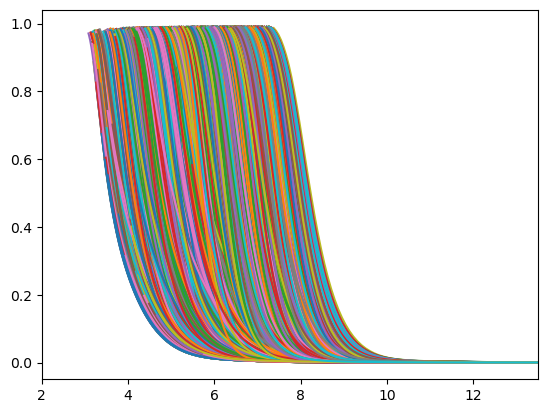

In [12]:

allxe=[]
zfin=[]
xefin=[]
tau =[]
plt.figure()

print(len(ion_histories.keys()))

for key in ion_histories.keys():
    z=np.array(ion_histories[key]["z"])
    xe=np.array(ion_histories[key]["xe"])
    allxe.append(np.vstack((z,xe)))
    zfin.append(z[-3])
    xefin.append(xe[-1])
   # tau.append(reio_mod.xe_to_tau(np.hstack((0,0.99*z[-1],z[::-1])), 1.08*np.hstack((1,1,xe[::-1]+1e-4))))
    plt.plot(z, xe)
plt.xlim(2, 13.5)
zfin  = np.array(zfin)
xefin  = np.array(xefin)

print(ion_histories["14858"])

[ 3.1   3.18  3.26  3.34  3.42  3.5   3.58  3.66  3.74  3.82  3.9   3.98
  4.06  4.14  4.22  4.3   4.38  4.46  4.54  4.62  4.7   4.78  4.86  4.94
  5.02  5.1   5.18  5.26  5.34  5.42  5.5   5.58  5.66  5.74  5.82  5.9
  5.98  6.06  6.14  6.22  6.3   6.38  6.46  6.54  6.62  6.7   6.78  6.86
  6.94  7.02  7.1   7.18  7.26  7.34  7.42  7.5   7.58  7.66  7.74  7.82
  7.9   7.98  8.06  8.14  8.22  8.3   8.38  8.46  8.54  8.62  8.7   8.78
  8.86  8.94  9.02  9.1   9.18  9.26  9.34  9.42  9.5   9.58  9.66  9.74
  9.82  9.9   9.98 10.06 10.14 10.22 10.3  10.38 10.46 10.54 10.62 10.7
 10.78 10.86 10.94 11.02]


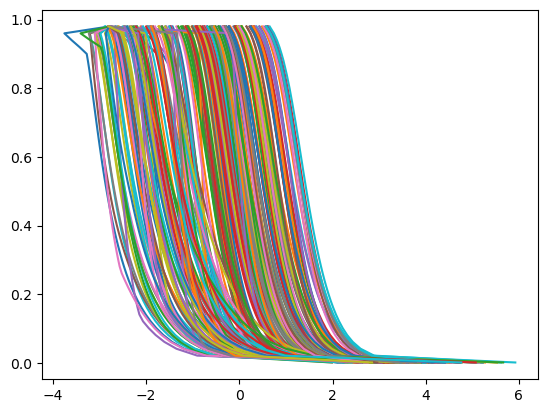

In [13]:
#print(len(allxe))
#print(zfin.min())
#print(np.size(df.index ))

nz = 100
z_interp = np.arange(nz)/nz*8+3.1


nx=50
#xe_interp = np.arange(nx)/nx+0.01
xe_interp = np.linspace(0.001, 0.98, nx)

#xe_interp = np.logspace(np.log10(0.01), np.log10(0.98), nx)

print(z_interp)

z_interp = np.zeros((len(df.index), nx))
zem =[]
xemax=[]

for i,key in enumerate(df.index):
    #print(key)
    z=np.array(ion_histories[str(key)]["z"])
    xe=np.array(ion_histories[str(key)]["xe"])
    xemax.append(np.max(xe))
    if np.max(xe)<0.98:
        xe[xe==np.max(xe)]=0.97
        z[xe==np.max(xe)]-=0.5
    
    zem.append(np.mean(z[xe>0.01]))
    
    z_interp[i,:] = np.interp(np.log10(xe_interp), np.log10(xe), np.log10(z), left=np.log10(10), right=np.log10(4))


zm = np.mean(zem)
zs =  np.std(zem)

#print(xe_interp.shape, zm, zs)

for i in np.arange(250):
    plt.plot((10**z_interp[i,:]-zm)/zs, xe_interp[:])

['Xray_Lfunc', 'gasconversion_timescale', 'hard_Xray_fraction', 'log10_Mmin', 'ion_escapefrac_post']
(9401,)
9420


/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_57896/2663075386.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  allpars[i,j] = df[par][i]
/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_57896/2663075386.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  allpars[i,j] = np.log10(df[par][i])


0.0
(7655, 50)
[np.float64(0.000192), np.float64(2.8685856665587655), np.float64(0.0), np.float64(8.0)]
[np.float64(0.0192), np.float64(4.021383654057061), np.float64(1.0), np.float64(9.742176558101873)]


([<matplotlib.axis.XTick at 0x311c83910>,
 [Text(0, 0, 'Xray_Lfunc'),
  Text(1, 0, 'gasconversion_timescale'),
  Text(2, 0, 'hard_Xray_fraction'),
  Text(3, 0, 'log10_Mmin'),
  Text(4, 0, 'ion_escapefrac_post')])

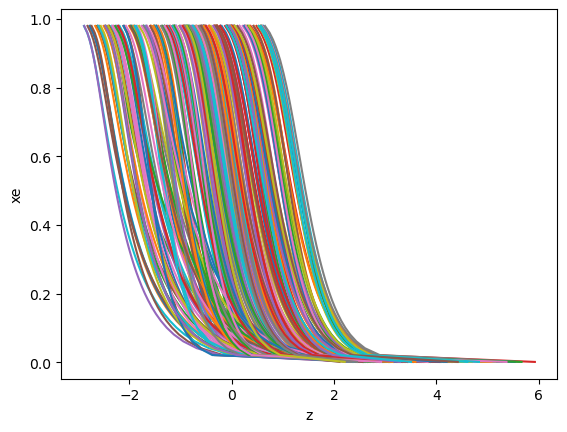

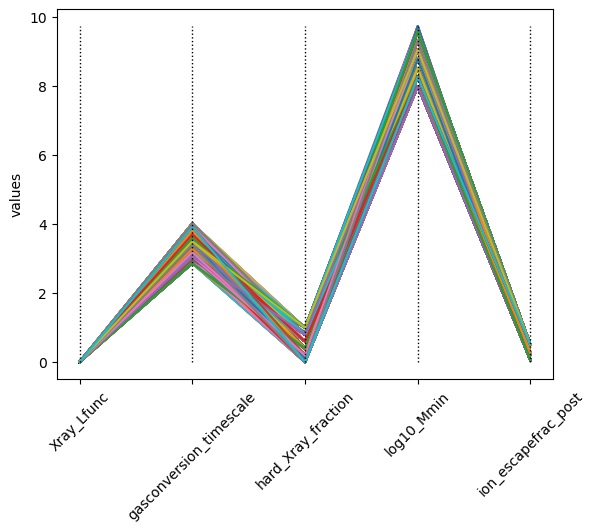

In [14]:
parkey =  ['Xray_Lfunc', 'gasconversion_timescale', 'hard_Xray_fraction', 'log10_Mmin', 'ion_escapefrac_post']
#parkey =  ['gasconversion_timescale', 'hard_Xray_fraction', 'log10_Mmin', 'ion_escapefrac_post']
#parkey =  df.keys()[1:]
print(parkey)
print(np.shape(df[parkey[0]]))
print(len(allxe))

allpars = np.zeros((len(df.index), len(parkey)))
#allpars=[]
allp=[]
zz_tokeep =[]

for i,key in enumerate(df.index):
    for j,par in enumerate(parkey):
        #print(np.shape(df[par][i]),i,j, df[par][i])
        allpars[i,j] = df[par][i]
        if par == 'gasconversion_timescale':
            allpars[i,j] = np.log10(df[par][i])
        


for i,key in enumerate(df.index):
    if (xemax[i] > 0.98): # and (allpars[i,2]>1e-2):
        allp.append(allpars[i,:])
        #xe_tokeep.append(xe_interp[i,:])
        #allpars.append(allp)
        zz_tokeep.append(z_interp[i,:])

zz_tokeep = np.array(zz_tokeep)
#print(allp)
allpars  = np.array(allp) #np.log(np.array(allp)+1e-5)
#allpars = np.reshape(np.array(allpars), (np.shape(zz_tokeep))[0], np.size(parkey))
print(allpars.min())
print(zz_tokeep.shape)

print([np.min(allpars[:,i]) for i in np.arange(4)])
print([np.max(allpars[:,i]) for i in np.arange(4)])

for i in np.arange(250):
    plt.plot((10**zz_tokeep[i,:]-zm)/zs, xe_interp[:])
plt.ylabel('xe')
plt.xlabel('z')

plt.figure()
parmeans = np.mean(allpars, axis=0)
parstd = np.std(allpars, axis=0)

for i in np.arange(2500):
    plt.plot((allpars[i,:]))


for i in np.arange(np.size(parkey)):
    #plt.plot(np.arange(np.size(allpars[:,i])), allpars[:,i], 'o')
    plt.vlines(i, np.min(allpars), np.max(allpars), color='k', lw=1,ls=":")   

plt.ylabel('values')
#plt.xlabel(parkey)
plt.xticks(np.arange(np.size(parkey)), labels=parkey, rotation=45)



In [15]:

# Generate sample training data
np.random.seed(0)

XX_train = (allpars-parmeans)/parstd
yy_train = (10**zz_tokeep-zm)/zs #zz_tokeep

# Split data into training and validation sets (e.g., 80% train, 20% validation)

#val_split_index2 = int(0.9 * len(X_train))
#X_test, y_test = X_train[val_split_index2:], y_train[val_split_index2:]
#val_split_index = int(0.8 * len(X_train))
#X_val, y_val = X_train[val_split_index:val_split_index2], y_train[val_split_index:val_split_index2]
#X_train, y_train = X_train[:val_split_index], y_train[:val_split_index]


X_train, X_test, y_train, y_test = train_test_split(XX_train, yy_train, test_size=0.10, random_state=0)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=0)



print(np.shape(X_val), np.shape(y_val   ))
print(np.shape(X_train), np.shape(y_train   ))
print(np.shape(X_test), np.shape(y_test))

#print(X_test, y_test)


(1378, 5) (1378, 50)
(5511, 5) (5511, 50)
(766, 5) (766, 50)


In [16]:

# Define a custom loss function
def custom_loss(y_true, y_pred):
    loss = tf.reduce_mean(tf.losses.binary_crossentropy(y_true, y_pred))
    return loss + 0.01 * tf.reduce_sum(y_pred)  # Adding a small regularization term as an example


layer_norm = tf.keras.layers.Normalization()
layer_norm.adapt(X_train)


# Define the model
model = keras.Sequential([
    layer_norm,
    layers.Dense(nx, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(nx, activation='relu'),
    layers.Dense(nx, activation='relu'),
    #layers.Dense(nx, activation='relu'),
    layers.Dense(nx, activation='relu'),
    layers.Dense(nx, activation='linear')#'softmax' 'sigmoid'
])

# Compile the model with the custom loss
#model.compile(optimizer='adam', loss=custom_loss, metrics=['accuracy'])
#loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

#model.compile(optimizer='adam',loss='mse', metrics=['accuracy'])
model.compile(optimizer='adam',loss='mse', metrics=[tf.keras.metrics.MeanSquaredError()])
# Train the model with validation data

history = model.fit(X_train, y_train, epochs=600, batch_size=35, validation_data=(X_val, y_val))



Epoch 1/600


/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 992us/step - loss: 0.7763 - mean_squared_error: 0.7763 - val_loss: 0.0216 - val_mean_squared_error: 0.0216
Epoch 2/600
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step - loss: 0.0169 - mean_squared_error: 0.0169 - val_loss: 0.0087 - val_mean_squared_error: 0.0087
Epoch 3/600
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - loss: 0.0078 - mean_squared_error: 0.0078 - val_loss: 0.0056 - val_mean_squared_error: 0.0056
Epoch 4/600
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step - loss: 0.0045 - mean_squared_error: 0.0045 - val_loss: 0.0033 - val_mean_squared_error: 0.0033
Epoch 5/600
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0029 - mean_squared_error: 0.0029 - val_loss: 0.0027 - val_mean_squared_error: 0.0027
Epoch 6/600
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step - loss: 0.0024 - mean_squared_error: 0.0024 - val_loss: 0.0019 - val_mean_squared_error: 0.0019
Epoch 7/600
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step - loss: 0.0020 - mean_squared_error: 0.0020 - val_los

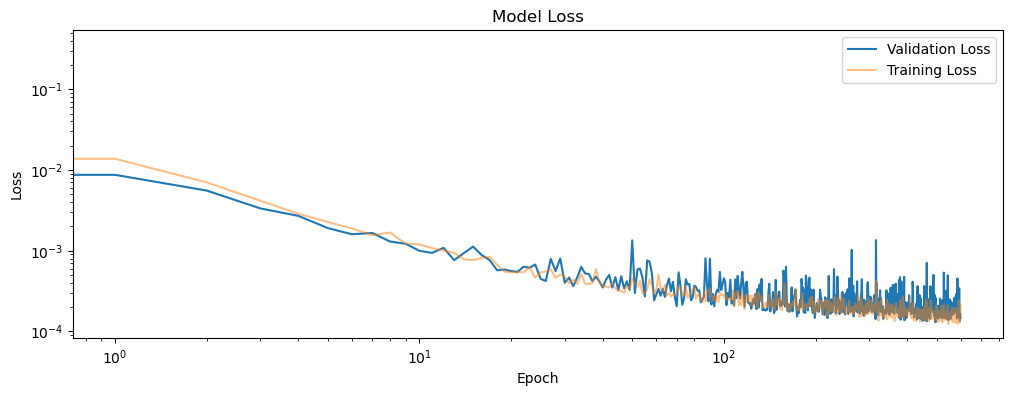

In [17]:
# Plot training & validation loss values
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
#plt.loglog(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.loglog(history.history['loss'], label='Training Loss', alpha=0.5)

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
(766, 50) (766, 5)


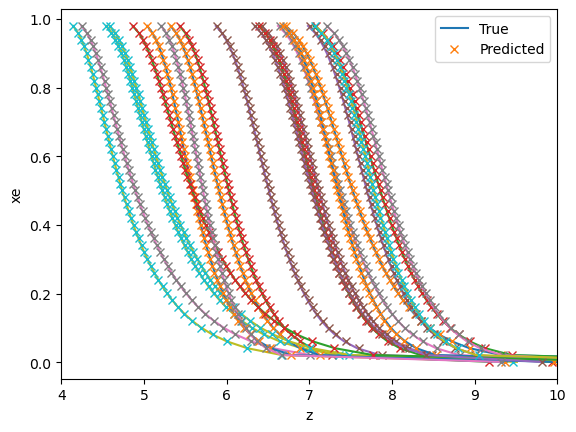

In [18]:
Y_test = history.model.predict(X_test)


print(np.shape(Y_test),np.shape(X_test))
plt.figure()
deb=35
for i in np.arange(20)+deb:
    #plt.plot(z_interp, y_test[i], label='True')
    #plt.plot(z_interp, Y_test[i], "x", label='Predicted')
    if i ==deb :
        plt.plot(y_test[i]*zs+zm, xe_interp, label='True')
        plt.plot(Y_test[i]*zs+zm, xe_interp, "x", label='Predicted')
    else:
        plt.plot(y_test[i]*zs+zm, xe_interp)
        plt.plot(Y_test[i]*zs+zm, xe_interp, "x")
    #print(Y_test[i,10])
    plt.legend()
    plt.ylabel('xe')
    plt.xlabel('z')
    plt.xlim(4,10)
    

In [19]:
print(np.shape(y_test), np.shape(Y_test))


(766, 50) (766, 50)


0.030962194675491942


/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_57896/1195368032.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


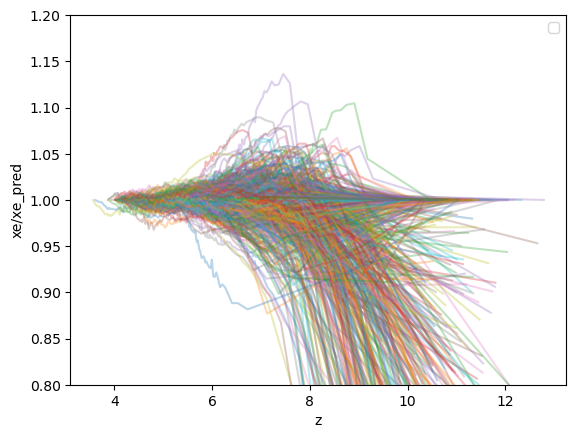

In [20]:
deb=35
trucratio = np.zeros((np.shape(y_test)[0], nx))

for i in np.arange(np.shape(y_test)[0]):
    #plt.plot(z_interp, y_test[i], label='True')
    #plt.plot(z_interp, Y_test[i], "x", label='Predicted')
    #plt.plot(xe_interp,y_test[i]/Y_test[i], alpha=0.5)
    
    #plt.plot(y_test[i]*zs+zm, xe_interp)
    #plt.plot(y_test[i]*zs+zm, np.interp(y_test[i,::-1]*zs+zm, Y_test[i,::-1]*zs+zm, xe_interp[::-1])[::-1], "x")
    plt.plot(y_test[i]*zs+zm, xe_interp/np.interp(y_test[i,::-1]*zs+zm, Y_test[i,::-1]*zs+zm, xe_interp[::-1])[::-1], alpha=0.3)
    trucratio[i,:]  = (xe_interp/np.interp(y_test[i,::-1]*zs+zm, Y_test[i,::-1]*zs+zm, xe_interp[::-1])[::-1])
    plt.legend()
    plt.ylabel('xe/xe_pred')
    plt.xlabel('z')
    #plt.xlim(0,1)
    plt.ylim(0.8,1.2)

print(np.std(trucratio))
    

NameError: name 'reio_mod' is not defined

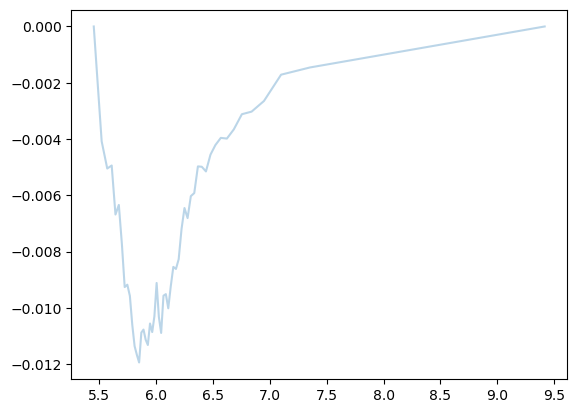

In [21]:
# tau_true = np.zeros((np.shape(y_test)[0]))
# tau_pred = np.zeros((np.shape(y_test)[0]))

# truc = np.zeros((np.shape(y_test)[0], nx))

# for i in np.arange(np.shape(y_test)[0]):
#     #plt.plot(z_interp, y_test[i], label='True')
#     #plt.plot(z_interp, Y_test[i], "x", label='Predicted')
#     #plt.plot(xe_interp,y_test[i]/Y_test[i], alpha=0.5)
    
#     #plt.plot(y_test[i]*zs+zm, xe_interp)
#     #plt.plot(y_test[i]*zs+zm, np.interp(y_test[i,::-1]*zs+zm, Y_test[i,::-1]*zs+zm, xe_interp[::-1])[::-1], "x")
#     plt.plot(y_test[i]*zs+zm, (xe_interp-np.interp(y_test[i,::-1]*zs+zm, Y_test[i,::-1]*zs+zm, xe_interp[::-1])[::-1]), alpha=0.3)

#     truc[i,:]  = (xe_interp-np.interp(y_test[i,::-1]*zs+zm, Y_test[i,::-1]*zs+zm, xe_interp[::-1])[::-1])
#     tau_true[i]= reio_mod.xe_to_tau(y_test[i,::-1]*zs+zm, xe_interp[::-1])
#     tau_pred[i] = reio_mod.xe_to_tau(y_test[i,::-1]*zs+zm, (np.interp(y_test[i,::-1]*zs+zm, Y_test[i,::-1]*zs+zm, xe_interp[::-1])))
#     plt.legend()
#     plt.ylabel('xe-xe_pred')
#     plt.xlabel('z')
#     #plt.xlim(0,1)
#     plt.ylim(-0.1,0.1)


Text(0.5, 0, 'xe')

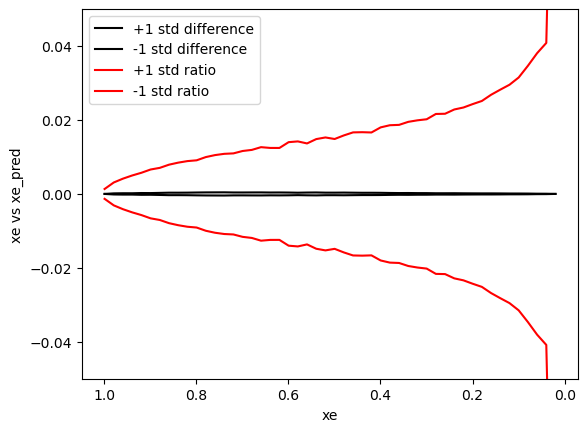

In [22]:

plt.figure()
plt.plot(xe_interp[::-1], np.std(truc,axis=0),"k" ,alpha=1, label="+1 std difference")
plt.plot(xe_interp[::-1], -np.std(truc,axis=0),"k", alpha=1, label="-1 std difference")
plt.plot(xe_interp[::-1], np.std(trucratio,axis=0),"r" ,alpha=1, label="+1 std ratio")
plt.plot(xe_interp[::-1], -np.std(trucratio,axis=0),"r", alpha=1, label="-1 std ratio")

plt.xticks(np.arange(6)/5, labels=np.round(1.0-np.arange(6)/5., decimals=1), rotation=0)
plt.ylim(-0.05,0.05)
plt.legend()
plt.ylabel('xe vs xe_pred')
plt.xlabel('xe')
 

Text(0, 0.5, 'tau_pred')

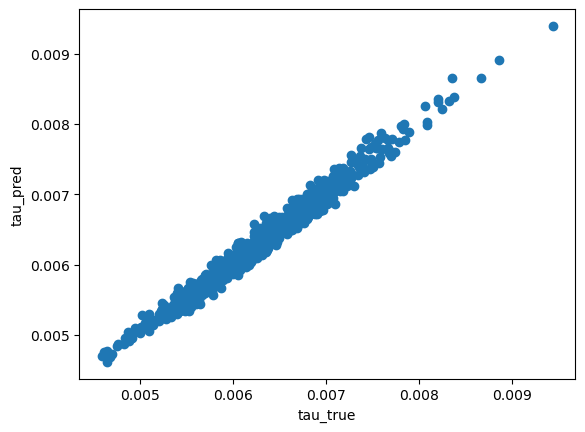

In [ ]:
plt.scatter(tau_true,tau_pred) 
plt.xlabel('tau_true')
plt.ylabel('tau_pred')

0.01684897587998952


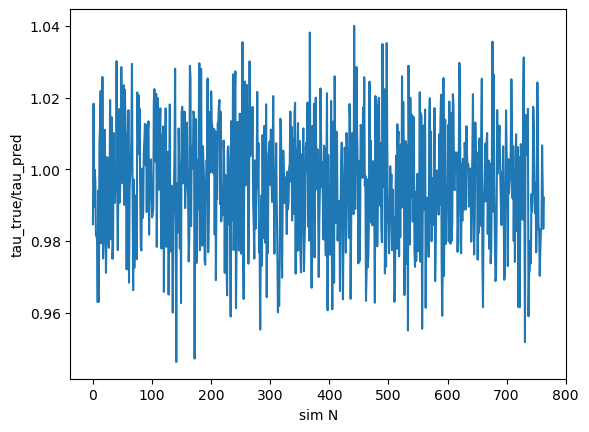

In [ ]:
plt.plot(tau_true/tau_pred) 
plt.xlabel("sim N")
plt.ylabel('tau_true/tau_pred')
print(np.std(tau_true/tau_pred))

In [ ]:
np.__version__


'1.26.4'

In [28]:
model.save("model.keras")
parmeansstd = {'fX':{"mean":parmeans[0], "std":parstd[0]}, 'rHS':{"mean":parmeans[1], "std":parstd[1]}, 'tau':{"mean":parmeans[2],
                "std":parstd[2]}, 'Mmin':{"mean":parmeans[3], "std":parstd[3]}, 'fesc':{"mean":parmeans[4], "std":parstd[4]}}

np.save("pmean_pstd_zm_zs_xev.npy", {"parmeansstd":parmeansstd ,"zm":zm, "zs":zs, "xe_int":xe_interp})


In [34]:
Y_test / model.predict(X_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step


array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], dtype=float32)

In [40]:
zm / data.item()["zm"], zs / data.item()["zs"]

(np.float64(1.0), np.float64(1.0))

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step
(766, 50) (766, 5)


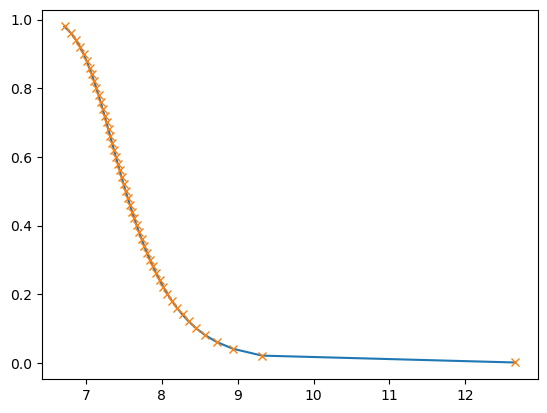

In [39]:
Y_test = history.model.predict(X_test)


print(np.shape(Y_test),np.shape(X_test))
plt.figure()
deb=35
for i in np.arange(20)+deb:
    #plt.plot(z_interp, y_test[i], label='True')
    #plt.plot(z_interp, Y_test[i], "x", label='Predicted')
    if i ==deb :
        plt.plot(y_test[i]*zs+zm, xe_interp, label='True')
        plt.plot(Y_test[i]*zs+zm, xe_interp, "x", label='Predicted')

In [52]:
df.columns.to_numpy()

array(['debug', 'restart', 'restart_N', 't_final', 'box_size', 'sortie',
       'diagnosis_n', 'collisions', 'boundary_condition', 'dtime',
       'theta', 'eps', 'use_quad', 'use_cosmo', 'use_cooling',
       'use_sticky', 'UO', 'ncrit', 'just_radiative', 'use_quasar',
       'only_dynamic', 'UV_RT_dynamic_use', 'use_Helium', 'LyA_from_Xray',
       'save_lightcones', 'elasticity_params', 'ion_escapefrac',
       'Xray_Lfunc', 'overdensity_thresh', 'gasconversion_timescale',
       'feedback_efficiency', 'hard_Xray_fraction', 'log10_Mmin',
       'ion_escapefrac_thresh', 'ion_escapefrac_post', 'z_start', 'z_mid',
       'z_end', 'A', 'duration'], dtype=object)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


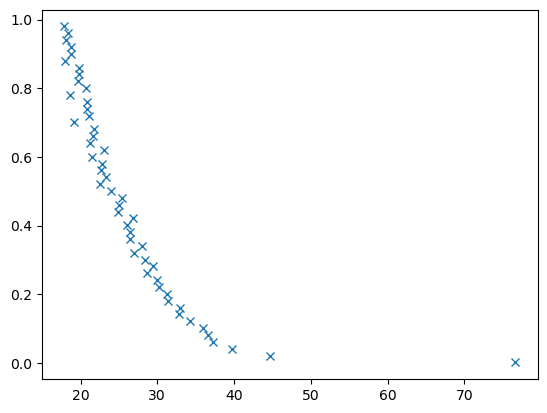

In [46]:
model = keras.models.load_model(f'/Users/emcbride/alfred/model.keras')
data = np.load("pmean_pstd_zm_zs_xev.npy", allow_pickle=True)


z_fin  = np.arange(10000)/500.+1e-1

#params = {'fX':-2.71669877 ,  'rHS':0.2        , 'tau': 3.51074603  , 'Mmin':9.33       , 'fesc': 0.275 }
params = {'fX':1.02994486, 'rHS':-0.27050967, 'tau':-1.4320606, 'Mmin':0.58003171, 'fesc':1.0414419}



parmeansstd = data.item()["parmeansstd"]
zm = data.item()["zm"]    
zs = data.item()["zs"]
xe_interp = data.item()["xe_int"]


X0_values = np.array([(params[key]-parmeansstd[key]["mean"])/parmeansstd[key]["std"] for key in params.keys()])
Yval = model.predict(X0_values[None,:])

plt.plot(Yval[0].T*zs+zm, xe_interp, "x")


[0.1        5.18192374 5.28767729 5.35122204 5.39873648 5.43328667
 5.46718836 5.4959507  5.51978397 5.54295874 5.56719923 5.59004211
 5.60644579 5.62749624 5.64805889 5.667377   5.68575096 5.70276642
 5.72295284 5.74078369 5.76013851 5.77888584 5.79576445 5.81515408
 5.83381557 5.85446501 5.8744626  5.89623165 5.91799784 5.93595076
 5.95940256 5.9825201  6.00603628 6.03320217 6.05826426 6.08561039
 6.1133194  6.14475965 6.17607832 6.20862913 6.24511147 6.28668642
 6.32998562 6.37534094 6.42994499 6.48895597 6.55785656 6.64353132
 6.75026178 6.89704418 7.14449263 8.70289135 8.87694918] [1.00000000e+00 1.00000000e+00 9.80000000e-01 9.60020408e-01
 9.40040816e-01 9.20061224e-01 9.00081633e-01 8.80102041e-01
 8.60122449e-01 8.40142857e-01 8.20163265e-01 8.00183673e-01
 7.80204082e-01 7.60224490e-01 7.40244898e-01 7.20265306e-01
 7.00285714e-01 6.80306122e-01 6.60326531e-01 6.40346939e-01
 6.20367347e-01 6.00387755e-01 5.80408163e-01 5.60428571e-01
 5.40448980e-01 5.20469388e-01 5.00489796

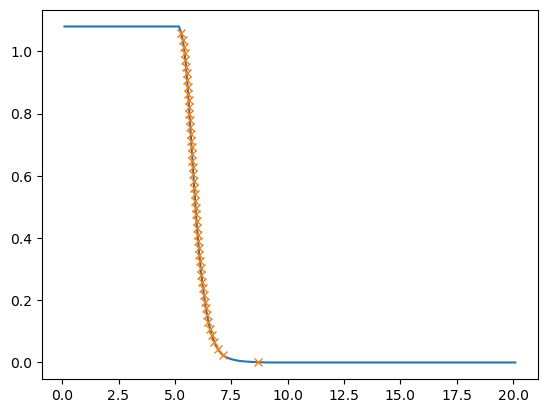

In [ ]:

zval = (Yval.T * zs + zm).flatten()[::-1]
x_vals = np.hstack(([1e-1,0.98*zval[0]],zval.flatten()))
x_vals = np.hstack((x_vals,[1.02*zval[-1]]))
                    
y_vals = np.hstack(([1,1],xe_interp.flatten()[::-1]))
y_vals = np.hstack((y_vals,[0.5*y_vals[-1]]))

print(x_vals,y_vals)

xe_fin = 1.08* 10**(np.interp(np.log10(z_fin), np.log10(x_vals), np.log10(y_vals), left=np.log10(1), right=-10))


plt.plot(z_fin, xe_fin)
plt.plot(Yval.T*zs+zm, 1.08*xe_interp, "x")

print(np.min(xe_fin), np.max(xe_fin))

In [ ]:
parkey

Index(['fX', 'rHS', 'tau', 'Mmin', 'fesc'], dtype='object')

In [ ]:
print(allpars[1000,:])


[-2.71669877  0.2         3.51074603  9.33        0.275     ]
